In [1]:
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.io
import pydmd, STQP, _utils

from matplotlib.patches import Circle
from mpl_toolkits.mplot3d import Axes3D
from sklearn.metrics import mean_squared_error

import warnings
warnings.simplefilter('ignore')
np.random.seed(42)

AXIS_LABEL_SIZE = 14
TICK_LABEL_SIZE = 12
LEGEND_SIZE = 12

In [2]:
# parameter settings
TRAIN_LEN = 300     # traing data length
PRED_LEN = 100      # predicted data length
RANK = 20           # DMD rank
N_TIME = 400        # Total time steps
ENERGY_THRESHOLD = 0.99

# load data
file = "Data/cylinder_vel.mat"
data = scipy.io.loadmat(file)
print(data.keys())
u, v, x, y = data["u"], data["v"], data["x"], data["y"]
print(f"u: {u.shape}, v: {v.shape}, x: {x.shape}, y: {y.shape}")

# Select time steps
u, v = u[:, :, :N_TIME], v[:, :, :N_TIME]
print(f"{u.shape}")
nx, ny, nt = u.shape
n_space = nx * ny

# Constructing the matrix
X = np.zeros((2 * n_space, nt))
for k in range(nt):
    X[:n_space, k] = u[:, :, k].reshape(-1)
    X[n_space:, k] = v[:, :, k].reshape(-1)
print(f"matrix shape: {X.shape}")

# split training and test data
assert TRAIN_LEN + PRED_LEN <= nt, "Training plus prediction exceeded the total time steps!"

X_train = X[:, :TRAIN_LEN]
X_test = X[:, TRAIN_LEN:TRAIN_LEN + PRED_LEN]

print(f"train data: {X_train.shape}, test data: {X_test.shape}")

dict_keys(['__header__', '__version__', '__globals__', 'u', 'v', 'x', 'y'])
u: (135, 80, 8000), v: (135, 80, 8000), x: (135, 80), y: (135, 80)
(135, 80, 400)
matrix shape: (21600, 400)
train data: (21600, 300), test data: (21600, 100)


<span style="font-size: 1.3em;">Plot measured u & v</span>

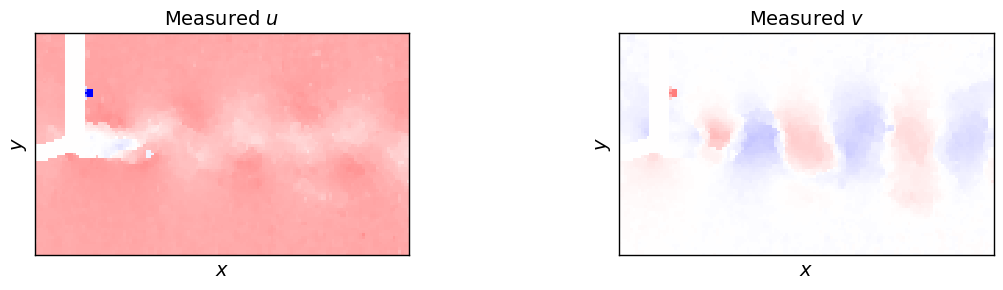

In [3]:
TIME_INDEX = 0
u0 = X[:n_space, TIME_INDEX].reshape(nx, ny)
v0 = X[n_space:, TIME_INDEX].reshape(nx, ny)
vmax = max(np.abs(u0).max(), np.abs(v0).max())
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3))
# Measured u
im1 = ax1.pcolormesh(x, y, u0, cmap='bwr', shading='auto', vmin=-vmax, vmax=vmax)
ax1.set_title(f'Measured $u$', fontsize=AXIS_LABEL_SIZE)
ax1.set_aspect('equal')
ax1.invert_yaxis()
ax1.set_xticks([])
ax1.set_yticks([])
ax1.set_xlabel('$x$', fontsize=AXIS_LABEL_SIZE)
ax1.set_ylabel('$y$', fontsize=AXIS_LABEL_SIZE)
for spine in ax1.spines.values():
    spine.set_color('black')
    spine.set_linewidth(1)
# Measured v
im2 = ax2.pcolormesh(x, y, v0, cmap='bwr', shading='auto', vmin=-vmax, vmax=vmax)
ax2.set_title(f'Measured $v$', fontsize=AXIS_LABEL_SIZE)
ax2.set_aspect('equal')
ax2.invert_yaxis()
ax2.set_xticks([])
ax2.set_yticks([])
ax2.set_xlabel('$x$', fontsize=AXIS_LABEL_SIZE)
ax2.set_ylabel('$y$', fontsize=AXIS_LABEL_SIZE)
for spine in ax2.spines.values():
    spine.set_color('black')
    spine.set_linewidth(1)

plt.tight_layout()
plt.show()

<span style="font-size: 1.3em;">Rank analysis</span>

In [8]:
rank_full = np.linalg.matrix_rank(X_train)
print(f"full rank: {rank_full}")

energy_rank = _utils.compute_energy_rank(X_train, energy_threshold=ENERGY_THRESHOLD)
print(f"{ENERGY_THRESHOLD*100}% energy rank: {energy_rank}")

full rank: 300
Singular values: [73.15190487  9.06370025  8.93907235  2.70621446  1.75511591  1.61182949
  1.52752831  1.45255907  1.31696565  1.30749544]...
Cumulative energy at rank 10: 0.9902
99.0% energy rank: 10


<span style="font-size: 1.3em;">Training STQP-DMD</span>

In [7]:
MU_VALUES = np.geomspace(1e-1, 1e0, num=10)
TIKHONOV_REG = 0
print("Training STQP-DMD...")
stqp_models = {}
for mu in MU_VALUES:
    stqp_dmd = STQP.stqpDMD(svd_rank=RANK, mu=mu, tikhonov_regularization=TIKHONOV_REG,use_csc=False, verbose=False).fit(X_train)
    stqp_models[f'mu_{mu:.4f}'] = stqp_dmd
    print(f"STQP-DMD (mu={mu:.4f}) reconstruction error: {mean_squared_error(stqp_dmd.reconstructed_data.real, X_train):.6e}")

Training STQP-DMD...
STQP-DMD (mu=0.1000) reconstruction error: 1.799639e-05
STQP-DMD (mu=0.1292) reconstruction error: 1.820859e-05
STQP-DMD (mu=0.1668) reconstruction error: 1.843646e-05
STQP-DMD (mu=0.2154) reconstruction error: 1.851238e-05
STQP-DMD (mu=0.2783) reconstruction error: 1.851238e-05
STQP-DMD (mu=0.3594) reconstruction error: 1.851238e-05
STQP-DMD (mu=0.4642) reconstruction error: 3.317241e-05
STQP-DMD (mu=0.5995) reconstruction error: 3.317241e-05
STQP-DMD (mu=0.7743) reconstruction error: 3.683445e-05
STQP-DMD (mu=1.0000) reconstruction error: 3.683445e-05


<span style="font-size: 1.3em;">Sparsity analysis</span>

In [8]:
print("number of non-zero coefficients in STQP-DMD:")
for mu_name, model in stqp_models.items():
    print(f"  {mu_name}: {_utils.count_nnz(model._b)}")

number of non-zero coefficients in STQP-DMD:
  mu_0.1000: 17
  mu_0.1292: 14
  mu_0.1668: 10
  mu_0.2154: 7
  mu_0.2783: 7
  mu_0.3594: 7
  mu_0.4642: 5
  mu_0.5995: 5
  mu_0.7743: 1
  mu_1.0000: 1


In [12]:
# Choose the best mu
best_mu_key = list(stqp_models.keys())[2]
stqp_dmd = stqp_models[best_mu_key]

<span style="font-size: 1.3em;">Plot measured u,v and reconstructed u,v</span>

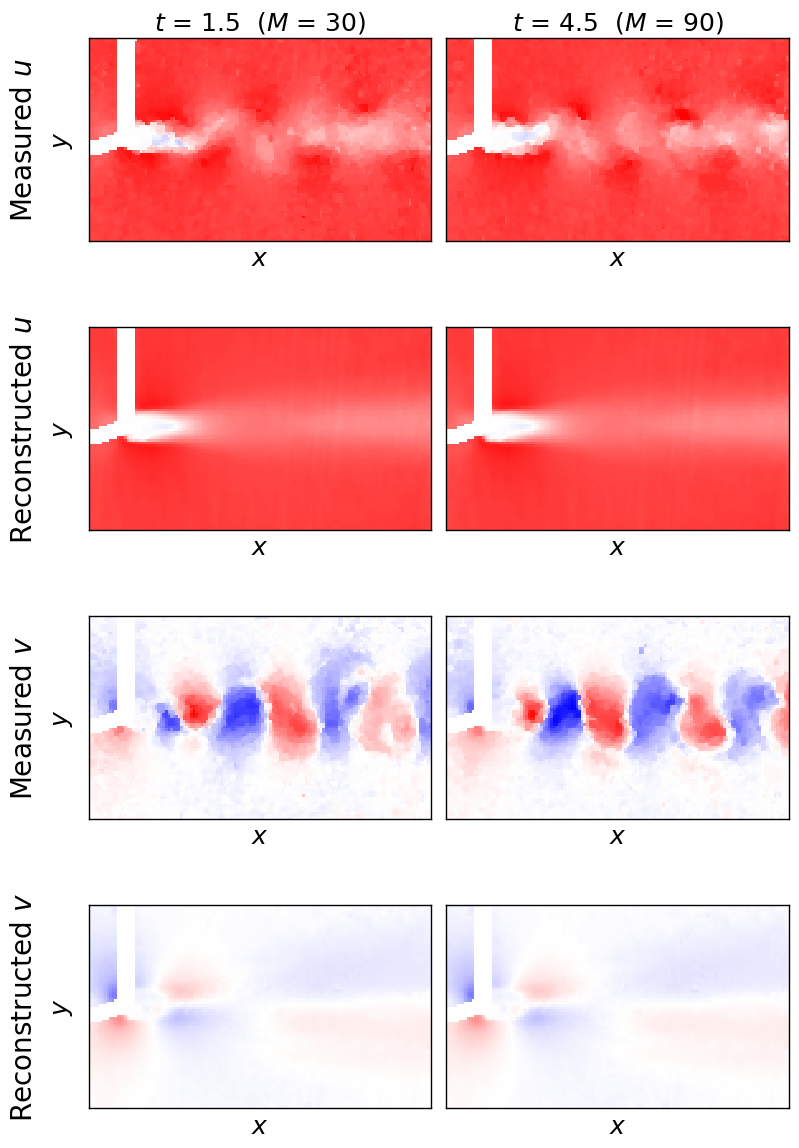

In [10]:
# Plot measured u,v and reconstructed u,v

# parameter setting 
time_steps = [30, 90]
n_steps = len(time_steps)
# Extract u and v for each time step (extracted from the original snapshot)
u_true_list = []
u_rec_list = []
v_true_list = []
v_rec_list = []

for k in time_steps:
    true_snap = X_train[:, k]                          # Measured snapshots
    true_u = true_snap[:n_space].reshape(nx, ny)       # true u
    true_v = true_snap[n_space:].reshape(nx, ny)       # true v
    
    rec_snap = stqp_dmd.reconstructed_data.real[:, k]  # STQP reconstructed snapshots
    rec_u = rec_snap[:n_space].reshape(nx, ny)         # true u
    rec_v = rec_snap[n_space:].reshape(nx, ny)         # true v
    
    u_true_list.append(true_u)
    u_rec_list.append(rec_u)
    v_true_list.append(true_v)
    v_rec_list.append(rec_v)

vmax_u = max([np.abs(u).max() for u in u_true_list + u_rec_list])
vmax_v = max([np.abs(v).max() for v in v_true_list + v_rec_list])

fig, axes = plt.subplots(4, n_steps, figsize=(4 * n_steps, 12))
if n_steps == 1:
    axes = axes.reshape(4, 1)

def setup_axis(ax, k, show_title=False):
    if show_title:
        ax.set_title(f'$t$ = {k*0.05}  ($M$ = {k})', fontsize=AXIS_LABEL_SIZE + 4)
    ax.set_aspect('equal')
    ax.invert_yaxis()
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_color('black')
        spine.set_linewidth(1)
    circle = Circle((1, 0), 0.5, fill=False, edgecolor='black', linewidth=1.5)
    ax.add_patch(circle)
    ax.set_xlabel('$x$', fontsize=AXIS_LABEL_SIZE + 4)

for i, k in enumerate(time_steps):
    ax = axes[0, i]
    ax.pcolormesh(x, y, u_true_list[i], cmap='bwr', shading='auto',vmin=-vmax_u, vmax=vmax_u)
    setup_axis(ax, k, show_title=True)

for i, k in enumerate(time_steps):
    ax = axes[1, i]
    ax.pcolormesh(x, y, u_rec_list[i], cmap='bwr', shading='auto',vmin=-vmax_u, vmax=vmax_u)
    setup_axis(ax, k, show_title=False)

for i, k in enumerate(time_steps):
    ax = axes[2, i]
    ax.pcolormesh(x, y, v_true_list[i], cmap='bwr', shading='auto',vmin=-vmax_v, vmax=vmax_v)
    setup_axis(ax, k, show_title=False)

for i, k in enumerate(time_steps):
    ax = axes[3, i]
    ax.pcolormesh(x, y, v_rec_list[i], cmap='bwr', shading='auto',vmin=-vmax_v, vmax=vmax_v)
    setup_axis(ax, k, show_title=False)

for row_idx in range(4):
    axes[row_idx, 0].set_ylabel('$y$', fontsize=AXIS_LABEL_SIZE + 4,rotation=90, labelpad=10)

plt.tight_layout(rect=[0.04, 0, 1, 1])

row_labels = ['Measured $u$', 'Reconstructed $u$','Measured $v$', 'Reconstructed $v$']
for row_idx, label in enumerate(row_labels):
    pos = axes[row_idx, 0].get_position()
    y_center = pos.y0 + pos.height / 2
    fig.text(0.025,y_center,label,fontsize=AXIS_LABEL_SIZE + 6,rotation=90,verticalalignment='center',horizontalalignment='center')

plt.show()

## Prediction

In [11]:
print(f"Start predicting {PRED_LEN} steps...")
X_exact = X_train.copy()
X_stqp = X_train.copy()
Y_pred_exact = [X_exact]
Y_pred_stqp = [X_stqp]

for _ in range(PRED_LEN):    
    y = stqp_dmd.predict(X_stqp[:, -1])
    Y_pred_stqp.append(y)
    X_stqp = np.column_stack((X_stqp[:, 1:], y))

Y_pred_stqp = np.column_stack(Y_pred_stqp)

Start predicting 100 steps...


<span style="font-size: 1.3em;">visualize prediction results</span>

In [12]:
# reload data
file = "Data/cylinder_vel.mat"
data = scipy.io.loadmat(file)
x = data["x"]
y = data["y"]
print(f"x shape: {x.shape}, y shape: {y.shape}")
NxNy = nx * ny
# Extracting prediction data
u_stqp = np.real(Y_pred_stqp[:NxNy, TRAIN_LEN:].reshape(nx, ny, PRED_LEN))
v_stqp = np.real(Y_pred_stqp[NxNy:, TRAIN_LEN:].reshape(nx, ny, PRED_LEN))
# true data
u_true = u[:, :, TRAIN_LEN:TRAIN_LEN+PRED_LEN]
v_true = v[:, :, TRAIN_LEN:TRAIN_LEN+PRED_LEN]

x shape: (135, 80), y shape: (135, 80)


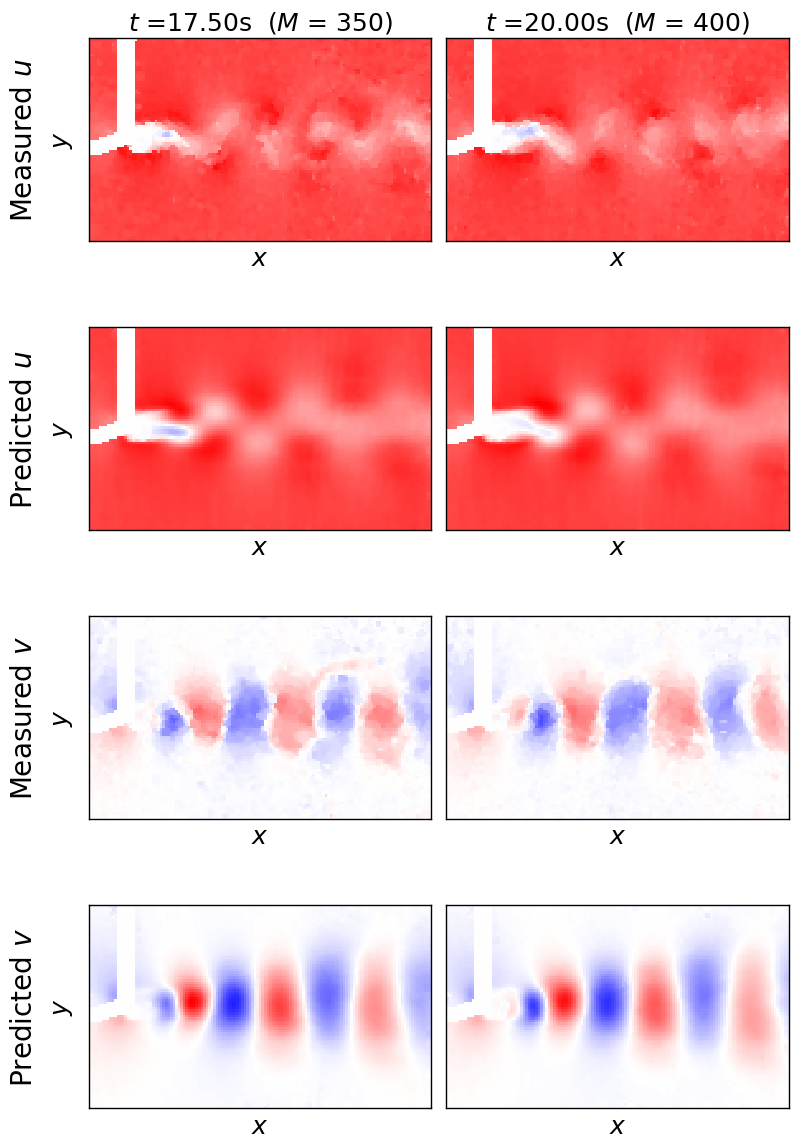

In [13]:
#plot
time_steps = [49, 99]
n_steps = len(time_steps)
u_true_list = []
u_pred_list = []
v_true_list = []
v_pred_list = []

for k in time_steps:
    u_true_k = u_true[:, :, k]
    v_true_k = v_true[:, :, k]

    u_pred_k = u_stqp[:, :, k]
    v_pred_k = v_stqp[:, :, k]

    u_true_list.append(u_true_k)
    u_pred_list.append(u_pred_k)

    v_true_list.append(v_true_k)
    v_pred_list.append(v_pred_k)

vmax_u = max([np.abs(u).max() for u in u_true_list + u_pred_list])
vmax_v = max([np.abs(v).max() for v in v_true_list + v_pred_list])

fig, axes = plt.subplots(4,n_steps,figsize=(4 * n_steps, 12))
if n_steps == 1:
    axes = axes.reshape(4, 1)
def setup_axis(ax, k, show_title=False):
    if show_title:ax.set_title(f'$t$ ={k*0.05+0.05 + 15:.2f}s  ($M$ = {301 + k})',fontsize=AXIS_LABEL_SIZE+4)
    ax.set_aspect('equal')
    ax.invert_yaxis()
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_color('black')
        spine.set_linewidth(1)
    circle = Circle((1, 0),0.5,fill=False,edgecolor='black',linewidth=1.5)
    ax.add_patch(circle)
    ax.set_xlabel('$x$',fontsize=AXIS_LABEL_SIZE+4)

for i, k in enumerate(time_steps):
    ax = axes[0, i]
    ax.pcolormesh(x,y,u_true_list[i],cmap='bwr',shading='auto',vmin=-vmax_u,vmax=vmax_u)
    setup_axis(ax,k,show_title=True)

for i, k in enumerate(time_steps):
    ax = axes[1, i]
    ax.pcolormesh(x,y,u_pred_list[i],cmap='bwr',
        shading='auto',vmin=-vmax_u,vmax=vmax_u)
    setup_axis(ax,k,show_title=False)

for i, k in enumerate(time_steps):
    ax = axes[2, i]
    ax.pcolormesh(x,y,v_true_list[i],cmap='bwr',
        shading='auto',vmin=-vmax_v,vmax=vmax_v)
    setup_axis(ax,k,show_title=False)

for i, k in enumerate(time_steps):
    ax = axes[3, i]
    ax.pcolormesh(x,y,v_pred_list[i],cmap='bwr',shading='auto',
        vmin=-vmax_v,vmax=vmax_v)
    setup_axis(ax,k,show_title=False)

for row_idx in range(4):
    axes[row_idx, 0].set_ylabel('$y$',fontsize=AXIS_LABEL_SIZE+4,
        rotation=90,labelpad=10)

plt.tight_layout(rect=[0.04, 0, 1, 1])

row_labels = ['Measured $u$','Predicted $u$','Measured $v$','Predicted $v$']
for row_idx, label in enumerate(row_labels):
    pos = axes[row_idx, 0].get_position()
    y_center = pos.y0 + pos.height / 2
    fig.text(0.025,y_center,label,fontsize=AXIS_LABEL_SIZE+6,rotation=90,verticalalignment='center',horizontalalignment='center')

plt.show()